## Overfitting

### **O que é Overfitting?**

O overfitting (sobreajuste em português) ocorre quando o modelo se adapta muito ao ruído dos dados de treino, ou seja, o modelo aprende muito bem apenas os dados de treino (função de erro tende a 0) mas não consegue se adaptar muito bem aos dados de teste (função de erro muito maior do que 0).

- **Exemplo 1**: Vamos supor que queiramos encontrar uma curva que explique o comportamento de 8 dados amostrais em um plano cartesiano. Caso escolhamos ajustar um polinômio de grau 7 (que possui 8 coeficientes), conseguimos interpolar exatamente todos os pontos, ou seja, a curva passa por todos eles e a função de erro no conjunto de treino é igual a zero. Contudo, esse modelo tende a se ajustar demais às particularidades da amostra, capturando inclusive ruídos ou variações aleatórias presentes nos dados. Como consequência, o polinômio pode apresentar oscilações exageradas fora dos pontos observados, produzindo previsões muito ruins para novos dados. Em outras palavras, o modelo se ajusta perfeitamente ao conjunto de treino, mas possui baixa capacidade de generalização. Contudo, um polinômio de grau menor pode não passar exatamente por todos os pontos, mas pode capturar melhor a tendência geral dos dados, resultando em previsões mais estáveis para observações futuras.

- **Exemplo 2**: Considere agora um problema de classificação resolvido com uma árvore de decisão. Suponha que temos um conjunto de treino com 100 observações. Se permitirmos que a árvore cresça sem nenhuma restrição (sem limitar profundidade, número mínimo de amostras por nó etc.), o algoritmo pode continuar criando divisões até que cada folha contenha apenas uma única observação. Nesse caso, cada nó final (folha) corresponde praticamente a uma amostra específica do conjunto de treino, o modelo memoriza exatamente os dados observados e o erro de treino tende a ser zero. Porém, quando um novo ponto é apresentado ao modelo, a árvore pode classificá-lo com base em regras extremamente específicas criadas apenas para separar os dados de treino. Como essas regras capturam detalhes muito particulares da amostra, o desempenho em dados novos tende a ser ruim.

### **Como amenizar o overfitting?**

Existem algumas formas de amenizar, ou até eliminar, o overfitting - geralmente, elas seguem o princípio de reduzir a variância do modelo ou equilibrar o bias com a variância. As principais são:

- **Aumentar o conjunto de dados**: Aumentando a quantidade de dados, permitimos que o modelo se torne mais complexo e seja capaz de se adpatar ao comportamento com mais liberdade.

- **Adicionar um regularizador**: Adicionamos um fator de regularização, que penaliza modelos muito complexos. Geralmente, adicionamos essa regularização na função de erro: $E'(w) = E(w) + \lambda g(w)$ (erro novo é o erro antigo mais uma função multiplicada pelo regularizador). Dessa forma, conseguimos entender a importância de algumas features para o aprendizado do modelo.

- **Diminuir a complexidade**: Diminuir a complexidade do modelo permite que ele tenha mais facilidade para se ajustar ao comportamento tendência dos dados.

- **Seleção de variáveis de interesse**: Para diminuir o overffiting podemos selecionar apenas as variáives de interesse, ignorando aquelas que, possivelmente, apenas aumentariam a complexidade do modelo e a dimensão do problema.

- **Cross-validation**: A cross-validation ajuda a escolher a complexidade ideal do modelo.

- **Poda**: Uma forma de resolver o problema do exemplo 2 é limitar o crescimento da árvore e realizar uma poda (remover partes do modelo que não estão contribuíndo muito para a performance geral do modelo).

- **Early Stopping**: Podemos também, durante o treinamento, quando o erro do treino está caindo e o erro de validação está subindo, podemos encerrar o processo.

### **Exemplo 1**
No exemplo 1, vamos ver que o overfitting não acompanha o comprotamento natural dos dados

In [228]:
# Bibliotecas usadas
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

In [229]:
# Construindo os dados com um ruído gaussiano
size = 10
x = np.linspace(0, 10, size)
noise = np.random.normal(0, .3, size)
y = np.sin(2*np.pi*x) + noise

X = x.reshape(-1,1)
x_plot = np.linspace(0,10,size).reshape(-1,1)

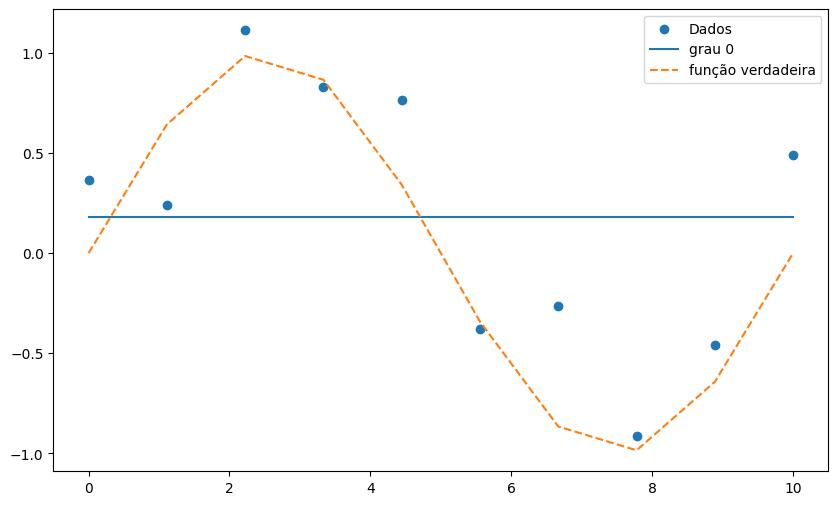

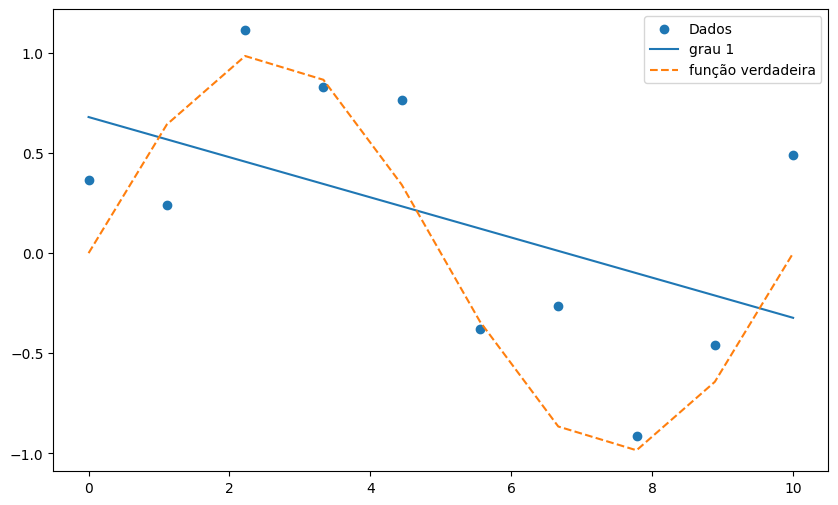

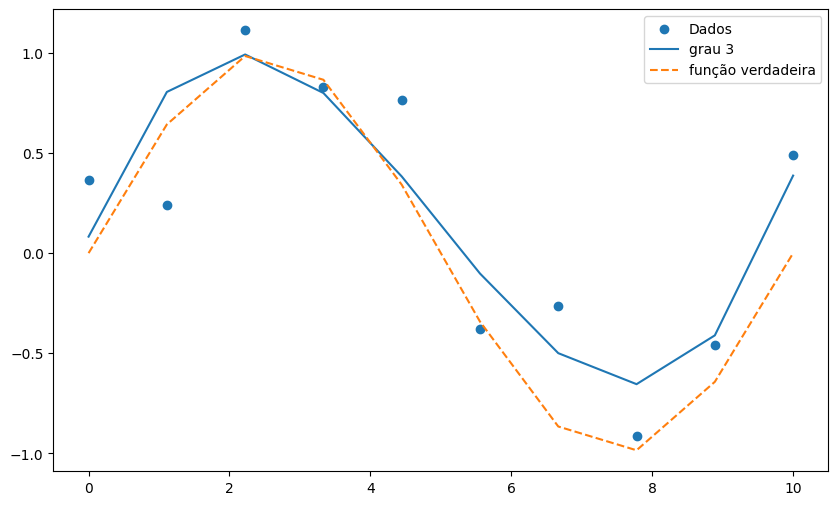

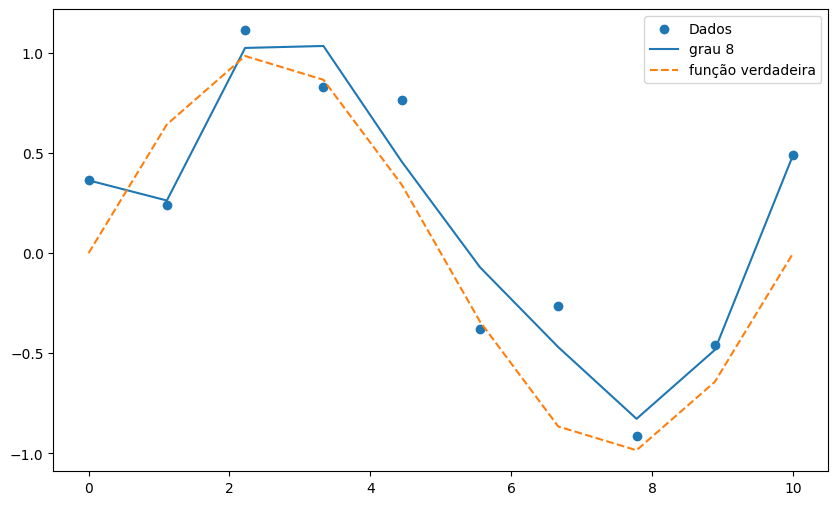

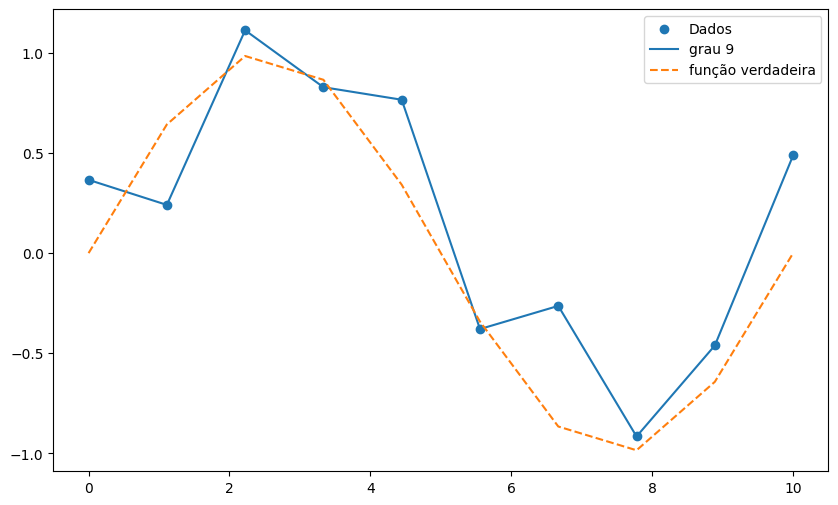

In [230]:
degrees = [0, 1, 3, 8, size-1]

for d in degrees:
    
    # Realizando uma regressão polinomial
    model = make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )
    model.fit(X,y)
    y_pred = model.predict(x_plot)

    # Plotando a figura comprando a curva prevista, o dados 
    # e a função verdadeira
    plt.figure(figsize=(10,6))
    plt.scatter(x,y,label="Dados")
    plt.plot(x_plot,y_pred,label=f"grau {d}")
    plt.plot(x_plot,np.sin(2*np.pi*x_plot),linestyle="--",label="função verdadeira")
    plt.legend()
    plt.show()

### **Exemplo 2**
O exemplo 2 mostra os erros de treino e validação, indicando o ponto em que poderíamos fazer um Early-Stopping

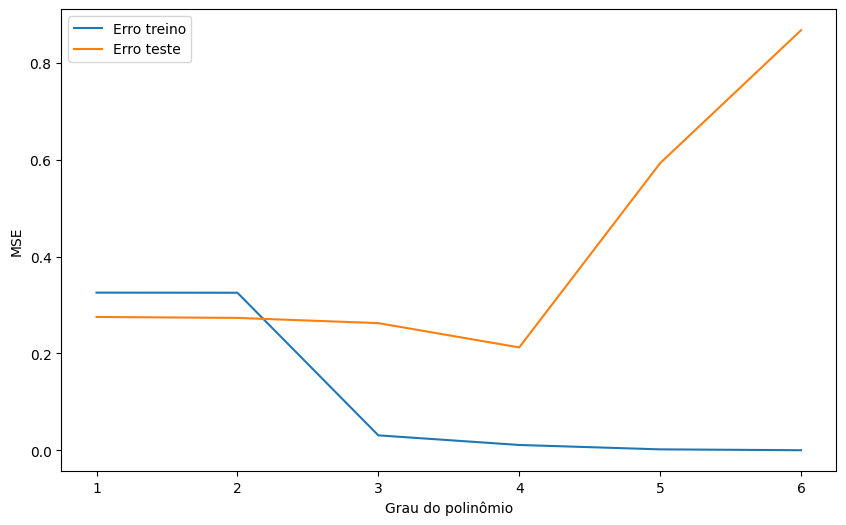

In [231]:
# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Exemplo de graus do polinômio
degrees = range(1,7)

# Criando as listas para armazenar os erros
train_errors = []
test_errors = []

# Treinando o modelo
for d in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree=d),
        LinearRegression()
    )
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plotando os gráficos
plt.figure(figsize=(10,6))
plt.plot(degrees, train_errors, label="Erro treino")
plt.plot(degrees, test_errors, label="Erro teste")
plt.xlabel("Grau do polinômio")
plt.ylabel("MSE")
plt.legend()
plt.show()

### **Exemplo 3**
No exemplo 3, vamos ver o fator de regularização nos erros de treino e teste

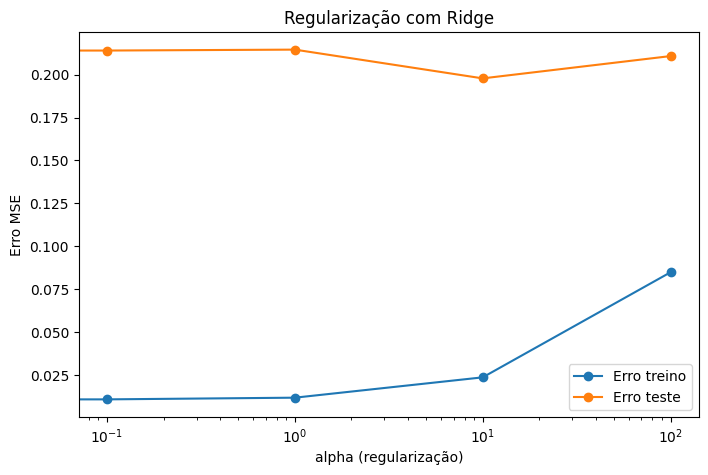

In [232]:
lambdas = [0, 0.1, 1, 10, 100]

train_errors = []
test_errors = []

for l in lambdas:

    model = make_pipeline(
        PolynomialFeatures(degree=4),
        Ridge(alpha=l)
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# gráfico
plt.figure(figsize=(8,5))
plt.plot(lambdas, train_errors, marker='o', label="Erro treino")
plt.plot(lambdas, test_errors, marker='o', label="Erro teste")

plt.xscale("log")
plt.xlabel("alpha (regularização)")
plt.ylabel("Erro MSE")
plt.title("Regularização com Ridge")
plt.legend()
plt.show()